# Task-2:Model Training and Evaluation

This notebook contains model training, Compare classificaion models for Fraud detection.


#### 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.metrics import f1_score

from sklearn.metrics import precision_recall_curve

from sklearn.metrics import auc

from sklearn.metrics import roc_auc_score

from sklearn.metrics import average_precision_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

import os

print("All libraries imported successfully")

All libraries imported successfully


#### Loading Prepared Data from Task 1

In [2]:
fraud_df = pd.read_csv('../data/processed/fraud_data_processed.csv')

credit_df = pd.read_csv('../data/processed/creditcard_processed.csv')

fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print("Datasets loaded successfully")
print(f"\nFraud Data {fraud_df.shape[0]:,} rows, {fraud_df.shape[1]} columns")
print(f"Credit Card  {credit_df.shape[0]:,} rows, {credit_df.shape[1]} columns")
print(f"\nFraud Data columns:")
print(list(fraud_df.columns))

Datasets loaded successfully

Fraud Data 129,146 rows, 22 columns
Credit Card  283,726 rows, 31 columns

Fraud Data columns:
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_address_int', 'lower_bound_ip_address', 'upper_bound_ip_address', 'country', 'time_since_signup', 'hour_of_day', 'day_of_week', 'day_of_month', 'transaction_count', 'transaction_velocity', 'is_new_account']


### Data Preparation

In [3]:
cols_to_drop = [
    'user_id',         
    'signup_time',      
    'purchase_time',    
    'ip_address',       
    'device_id',        
]

cols_to_drop = [c for c in cols_to_drop if c in fraud_df.columns]
fraud_model_df = fraud_df.drop(columns=cols_to_drop)

cat_cols = ['source', 'browser', 'sex', 'country']
cat_cols = [c for c in cat_cols if c in fraud_model_df.columns]

fraud_model_df = pd.get_dummies(
    fraud_model_df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

X_fraud = fraud_model_df.drop(columns=['class'])
y_fraud = fraud_model_df['class']

print("Fraud data prepared")
print(f"\nFeatures (X) shape : {X_fraud.shape}")
print(f"Target   (y) shape : {y_fraud.shape}")
print(f"\nFraud rate: {y_fraud.mean()*100:.2f}%")
print(f"Legitimate: {(y_fraud==0).sum():,}")
print(f"Fraud     : {(y_fraud==1).sum():,}")

Fraud data prepared

Features (X) shape : (129146, 199)
Target   (y) shape : (129146,)

Fraud rate: 9.50%
Legitimate: 116,878
Fraud     : 12,268


#### Preparing Credit Card Data for Modeling

In [4]:
X_credit = credit_df.drop(columns=['Class'])
y_credit = credit_df['Class']

print("Credit card data prepared")
print(f"\nFeatures (X) shape : {X_credit.shape}")
print(f"Target   (y) shape : {y_credit.shape}")
print(f"\nFraud rate: {y_credit.mean()*100:.4f}%")
print(f"Legitimate: {(y_credit==0).sum():,}")
print(f"Fraud     : {(y_credit==1).sum():,}")

Credit card data prepared

Features (X) shape : (283726, 30)
Target   (y) shape : (283726,)

Fraud rate: 0.1667%
Legitimate: 283,253
Fraud     : 473


#### Train Test Split

In [5]:
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud, y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

# --- Credit Card Split ---
X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit, y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

print("Data split complete")
print(f"\nFraud Data:")
print(f"  Training set : {X_fraud_train.shape[0]:,} rows")
print(f"  Testing set  : {X_fraud_test.shape[0]:,} rows")
print(f"  Train fraud rate : {y_fraud_train.mean()*100:.2f}%")
print(f"  Test  fraud rate : {y_fraud_test.mean()*100:.2f}%")
print(f"\nCredit Card:")
print(f"  Training set : {X_credit_train.shape[0]:,} rows")
print(f"  Testing set  : {X_credit_test.shape[0]:,} rows")
print(f"  Train fraud rate : {y_credit_train.mean()*100:.4f}%")
print(f"  Test  fraud rate : {y_credit_test.mean()*100:.4f}%")

Data split complete

Fraud Data:
  Training set : 103,316 rows
  Testing set  : 25,830 rows
  Train fraud rate : 9.50%
  Test  fraud rate : 9.50%

Credit Card:
  Training set : 226,980 rows
  Testing set  : 56,746 rows
  Train fraud rate : 0.1665%
  Test  fraud rate : 0.1674%


#### Applying SMOTE to Balance Training Data

In [6]:
smote = SMOTE(random_state=42)

# --- Apply SMOTE on Fraud Data training set ---
print("Applying SMOTE on Fraud Data...")
print(f"  Before: {(y_fraud_train==0).sum():,} legit | {(y_fraud_train==1).sum():,} fraud")

X_fraud_train_sm, y_fraud_train_sm = smote.fit_resample(
    X_fraud_train, y_fraud_train
)

print(f"  After : {(y_fraud_train_sm==0).sum():,} legit | {(y_fraud_train_sm==1).sum():,} fraud")

# --- Apply SMOTE on Credit Card training set ---
print("\nApplying SMOTE on Credit Card Data...")
print(f"  Before: {(y_credit_train==0).sum():,} legit | {(y_credit_train==1).sum():,} fraud")

X_credit_train_sm, y_credit_train_sm = smote.fit_resample(
    X_credit_train, y_credit_train
)

print(f"  After : {(y_credit_train_sm==0).sum():,} legit | {(y_credit_train_sm==1).sum():,} fraud")

print("\nSMOTE applied successfully on both datasets")
print("Test sets remain untouched")

Applying SMOTE on Fraud Data...
  Before: 93,502 legit | 9,814 fraud
  After : 93,502 legit | 93,502 fraud

Applying SMOTE on Credit Card Data...
  Before: 226,602 legit | 378 fraud
  After : 226,602 legit | 226,602 fraud

SMOTE applied successfully on both datasets
Test sets remain untouched


### Scale the Data

In [7]:
scaler_fraud = StandardScaler()
scaler_credit = StandardScaler()

# --- Scale Fraud Data ---
X_fraud_train_scaled = scaler_fraud.fit_transform(X_fraud_train_sm)

# NEVER fit on test data
X_fraud_test_scaled = scaler_fraud.transform(X_fraud_test)

# --- Scale Credit Card Data ---
X_credit_train_scaled = scaler_credit.fit_transform(X_credit_train_sm)
X_credit_test_scaled = scaler_credit.transform(X_credit_test)

print("Scaling complete")
print(f"\nFraud training set shape  : {X_fraud_train_scaled.shape}")
print(f"Fraud testing set shape   : {X_fraud_test_scaled.shape}")
print(f"\nCredit training set shape : {X_credit_train_scaled.shape}")
print(f"Credit testing set shape  : {X_credit_test_scaled.shape}")

Scaling complete

Fraud training set shape  : (187004, 199)
Fraud testing set shape   : (25830, 199)

Credit training set shape : (453204, 30)
Credit testing set shape  : (56746, 30)


### Training Models

#### Helper Function to evaluate ANY Model

In [8]:
def evaluate_model(model, X_test, y_test, model_name, dataset_name):
 
     # Get predictions
    y_pred = model.predict(X_test)

    # predict_proba() 
    y_prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_prob)

    # Confusion Matrix → shows all 4 outcomes
    cm = confusion_matrix(y_test, y_pred)

    # --- Print Results ---
    print(f"  {model_name} — {dataset_name}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  AUC-PR   : {auc_pr:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Fraud']))

    # --- Plot Confusion Matrix ---
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,          
        fmt='d',              
        cmap='Blues',         
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud']
    )
    plt.title(f'Confusion Matrix\n{model_name} — {dataset_name}')
    plt.ylabel('Actual')      
    plt.xlabel('Predicted')   
    plt.tight_layout()

    # Save the chart
    os.makedirs('../data/processed', exist_ok=True)
    filename = f"../data/processed/cm_{model_name.replace(' ','_')}_{dataset_name.replace(' ','_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

    # Return metrics
    return {'model': model_name, 'dataset': dataset_name,
            'f1': round(f1, 4), 'auc_pr': round(auc_pr, 4)}

print("Evaluation function ready")

Evaluation function ready


### Baseline Model - Logistic Regression

Training Logistic Regression...
Logistic Regression trained on Fraud Data
  Logistic Regression — Fraud Data
  F1 Score : 0.5773
  AUC-PR   : 0.6368

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.96     23376
       Fraud       0.59      0.56      0.58      2454

    accuracy                           0.92     25830
   macro avg       0.77      0.76      0.77     25830
weighted avg       0.92      0.92      0.92     25830



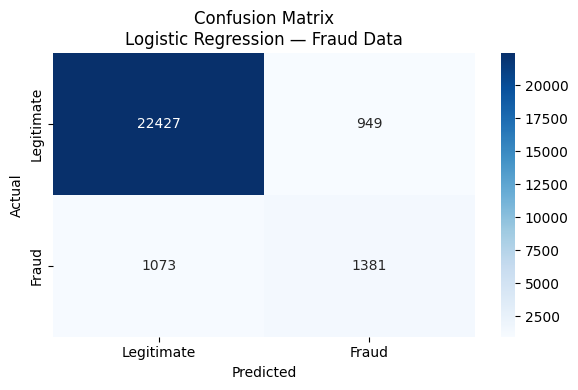

In [9]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced', 
    random_state=42
)

# --- Train on Fraud Data ---
lr_model.fit(X_fraud_train_scaled, y_fraud_train_sm)
print("Logistic Regression trained on Fraud Data")

# --- Evaluate on Fraud Data test set ---
lr_fraud_results = evaluate_model(
    lr_model,
    X_fraud_test_scaled,
    y_fraud_test,
    "Logistic Regression",
    "Fraud Data"
)

### Logistic Regression on Credit Card

Training Logistic Regression on Credit Card Data...
Logistic Regression trained on Credit Card Data
  Logistic Regression — Credit Card
  F1 Score : 0.2440
  AUC-PR   : 0.7027

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56651
       Fraud       0.14      0.85      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.62     56746
weighted avg       1.00      0.99      0.99     56746



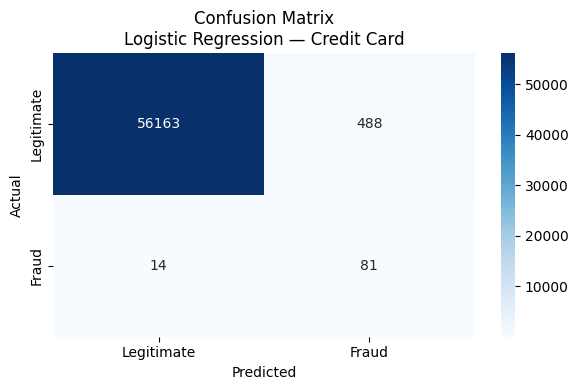

In [10]:
print("Training Logistic Regression on Credit Card Data...")

# Create fresh model for credit card data
lr_credit_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train on credit card training data
lr_credit_model.fit(X_credit_train_scaled, y_credit_train_sm)
print("Logistic Regression trained on Credit Card Data")

# Evaluate on credit card test set
lr_credit_results = evaluate_model(
    lr_credit_model,
    X_credit_test_scaled,
    y_credit_test,
    "Logistic Regression",
    "Credit Card"
)

### Random Forest

#### Train Random Forest with Hyperparameter Tuning - Fraud Data

Training Random Forest on Fraud Data...
Using 93,502 rows instead of 187,004
Random Forest trained on Fraud Data
  Random Forest — Fraud Data
  F1 Score : 0.6948
  AUC-PR   : 0.6357

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98     23376
       Fraud       0.95      0.55      0.69      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830



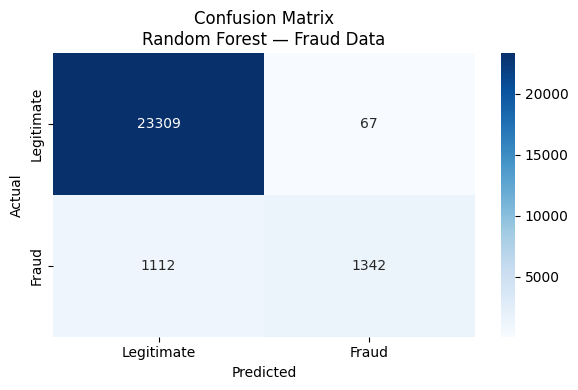

In [11]:
print("Training Random Forest on Fraud Data...")

from sklearn.utils import resample

X_sample_fraud, y_sample_fraud = resample(
    X_fraud_train_scaled,
    y_fraud_train_sm,
    n_samples=int(len(X_fraud_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample_fraud):,} rows instead of {len(X_fraud_train_scaled):,}")


rf_fraud_model = RandomForestClassifier(
    n_estimators=100,        
    max_depth=10,             
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1                 
)


rf_fraud_model.fit(X_sample_fraud, y_sample_fraud)
print("Random Forest trained on Fraud Data")


rf_fraud_results = evaluate_model(
    rf_fraud_model,
    X_fraud_test_scaled,
    y_fraud_test,
    "Random Forest",
    "Fraud Data"
)

###  Random Forest on Credit Card WITH Tuning

Training Random Forest on Credit Card Data...
Using 226,602 rows instead of 453,204
Random Forest trained on Credit Card Data
  Random Forest — Credit Card
  F1 Score : 0.6695
  AUC-PR   : 0.7924

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.56      0.83      0.67        95

    accuracy                           1.00     56746
   macro avg       0.78      0.92      0.83     56746
weighted avg       1.00      1.00      1.00     56746



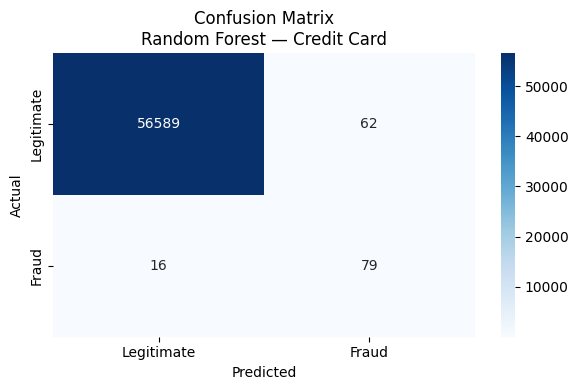

In [12]:
print("Training Random Forest on Credit Card Data...")


from sklearn.utils import resample
X_sample, y_sample = resample(
    X_credit_train_scaled,
    y_credit_train_sm,
    n_samples=int(len(X_credit_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample):,} rows instead of {len(X_credit_train_scaled):,}")

rf_credit_model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=10,            
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1                
)

rf_credit_model.fit(X_sample, y_sample)
print("Random Forest trained on Credit Card Data")

rf_credit_results = evaluate_model(
    rf_credit_model,
    X_credit_test_scaled,
    y_credit_test,
    "Random Forest",
    "Credit Card"
)

### XGBoost

### XGBoost on Fraud Data

Training XGBoost on Fraud Data...
Using 93,502 rows
XGBoost trained on Fraud Data
  XGBoost — Fraud Data
  F1 Score : 0.6057
  AUC-PR   : 0.6356

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96     23376
       Fraud       0.66      0.56      0.61      2454

    accuracy                           0.93     25830
   macro avg       0.81      0.76      0.78     25830
weighted avg       0.93      0.93      0.93     25830



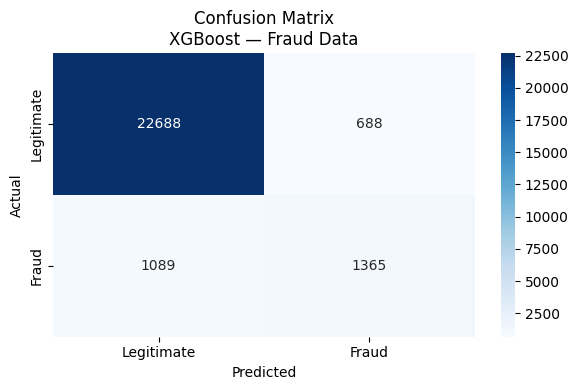

In [13]:
print("Training XGBoost on Fraud Data...")

from sklearn.utils import resample

X_sample_xgb_fraud, y_sample_xgb_fraud = resample(
    X_fraud_train_scaled,
    y_fraud_train_sm,
    n_samples=int(len(X_fraud_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample_xgb_fraud):,} rows")

fraud_ratio = (y_fraud_train_sm == 0).sum() / (y_fraud_train_sm == 1).sum()

xgb_fraud_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=fraud_ratio,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_fraud_model.fit(X_sample_xgb_fraud, y_sample_xgb_fraud)
print("XGBoost trained on Fraud Data")

xgb_fraud_results = evaluate_model(
    xgb_fraud_model,
    X_fraud_test_scaled,
    y_fraud_test,
    "XGBoost",
    "Fraud Data"
)

### XGBoost Credit Card

Training XGBoost on Credit Card Data...
Using 226,602 rows


XGBoost trained on Credit Card Data
  XGBoost — Credit Card
  F1 Score : 0.6367
  AUC-PR   : 0.8124

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.52      0.82      0.64        95

    accuracy                           1.00     56746
   macro avg       0.76      0.91      0.82     56746
weighted avg       1.00      1.00      1.00     56746



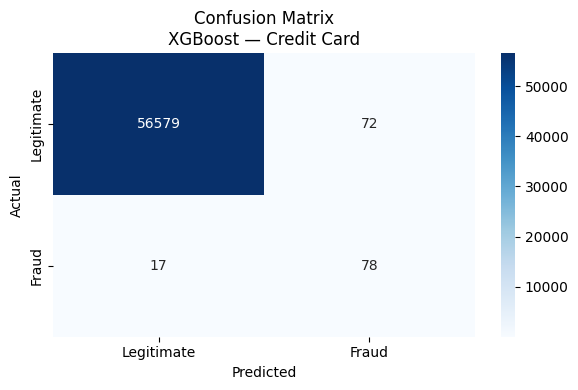

In [14]:
print("Training XGBoost on Credit Card Data...")

X_sample_xgb_credit, y_sample_xgb_credit = resample(
    X_credit_train_scaled,
    y_credit_train_sm,
    n_samples=int(len(X_credit_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample_xgb_credit):,} rows")

credit_ratio = (y_credit_train_sm == 0).sum() / (y_credit_train_sm == 1).sum()

xgb_credit_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=credit_ratio,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_credit_model.fit(X_sample_xgb_credit, y_sample_xgb_credit)
print("XGBoost trained on Credit Card Data")

xgb_credit_results = evaluate_model(
    xgb_credit_model,
    X_credit_test_scaled,
    y_credit_test,
    "XGBoost",
    "Credit Card"
)

### LightGBM

### LightGBM on Fraud Data

Training LightGBM on Fraud Data...
Using 93,502 rows
LightGBM trained on Fraud Data
  LightGBM — Fraud Data
  F1 Score : 0.6051
  AUC-PR   : 0.6362

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96     23376
       Fraud       0.67      0.56      0.61      2454

    accuracy                           0.93     25830
   macro avg       0.81      0.76      0.78     25830
weighted avg       0.93      0.93      0.93     25830



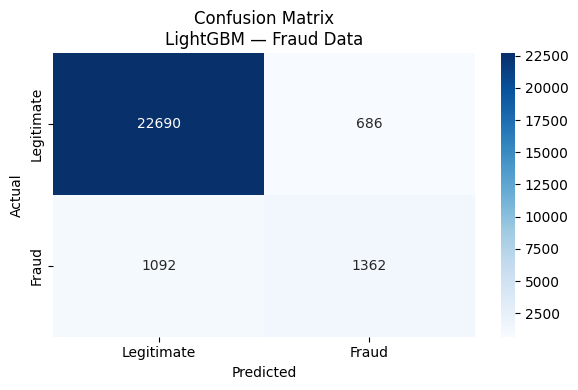

In [15]:
print("Training LightGBM on Fraud Data...")

X_sample_lgb_fraud, y_sample_lgb_fraud = resample(
    X_fraud_train_scaled,
    y_fraud_train_sm,
    n_samples=int(len(X_fraud_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample_lgb_fraud):,} rows")

lgb_fraud_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_fraud_model.fit(X_sample_lgb_fraud, y_sample_lgb_fraud)
print("LightGBM trained on Fraud Data")

lgb_fraud_results = evaluate_model(
    lgb_fraud_model,
    X_fraud_test_scaled,
    y_fraud_test,
    "LightGBM",
    "Fraud Data"
)

### LightGBM on Credit Card Data

Training LightGBM on Credit Card Data...
Using 226,602 rows
LightGBM trained on Credit Card Data
  LightGBM — Credit Card
  F1 Score : 0.6196
  AUC-PR   : 0.8139

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.49      0.83      0.62        95

    accuracy                           1.00     56746
   macro avg       0.75      0.92      0.81     56746
weighted avg       1.00      1.00      1.00     56746



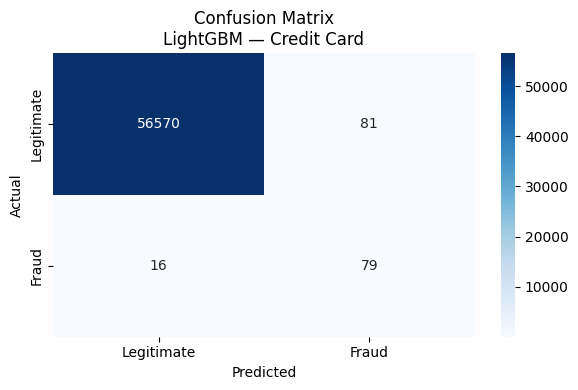

In [16]:
print("Training LightGBM on Credit Card Data...")

X_sample_lgb_credit, y_sample_lgb_credit = resample(
    X_credit_train_scaled,
    y_credit_train_sm,
    n_samples=int(len(X_credit_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample_lgb_credit):,} rows")

lgb_credit_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_credit_model.fit(X_sample_lgb_credit, y_sample_lgb_credit)
print("LightGBM trained on Credit Card Data")

lgb_credit_results = evaluate_model(
    lgb_credit_model,
    X_credit_test_scaled,
    y_credit_test,
    "LightGBM",
    "Credit Card"
)

In [30]:
# Create scaled version of ORIGINAL (smaller) data
scaler_fraud_orig = StandardScaler()
X_fraud_train_orig_scaled = scaler_fraud_orig.fit_transform(X_fraud_train)

scaler_credit_orig = StandardScaler()
X_credit_train_orig_scaled = scaler_credit_orig.fit_transform(X_credit_train)

print("Done")
print(X_fraud_train_orig_scaled.shape)
print(y_fraud_train.shape)

Done
(103316, 199)
(103316,)


### Cross Validation on the ALL models

In [31]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.utils import resample

print("Running Corrected Cross Validation...")

X_fraud_cv2, y_fraud_cv2 = resample(
    X_fraud_train_orig_scaled , y_fraud_train,
    n_samples=int(len(X_fraud_train_scaled) * 0.3),
    random_state=42, stratify=y_fraud_train
)

X_credit_cv2, y_credit_cv2 = resample(
    X_credit_train_orig_scaled , y_credit_train,
    n_samples=int(len(X_credit_train_scaled) * 0.3),
    random_state=42, stratify=y_credit_train
)

print(f"Fraud sample  : {len(X_fraud_cv2):,} rows")
print(f"Credit sample : {len(X_credit_cv2):,} rows")


skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_corrected_cv(model, X, y, name):
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=skf5, scoring='f1', n_jobs=-1)
    print(f"\n--- {name} ---")
    print(f"  Scores per fold : {[round(s,4) for s in scores]}")
    print(f"  Mean F1 Score   : {scores.mean():.4f}")
    print(f"  Std Deviation   : {scores.std():.4f}")
    return scores

print("FRAUD DATA — All 4 Models")


cv2_lr_fraud  = run_corrected_cv(
    LogisticRegression(max_iter=1000, random_state=42),
    X_fraud_cv2, y_fraud_cv2, "Logistic Regression"
)

cv2_rf_fraud  = run_corrected_cv(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    X_fraud_cv2, y_fraud_cv2, "Random Forest"
)

cv2_xgb_fraud = run_corrected_cv(
    XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss', n_jobs=-1),
    X_fraud_cv2, y_fraud_cv2, "XGBoost"
)

cv2_lgb_fraud = run_corrected_cv(
    LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    X_fraud_cv2, y_fraud_cv2, "LightGBM"
)

print("CREDIT CARD — All 4 Models")

cv2_lr_credit  = run_corrected_cv(
    LogisticRegression(max_iter=1000, random_state=42),
    X_credit_cv2, y_credit_cv2, "Logistic Regression"
)

cv2_rf_credit  = run_corrected_cv(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    X_credit_cv2, y_credit_cv2, "Random Forest"
)

cv2_xgb_credit = run_corrected_cv(
    XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss', n_jobs=-1),
    X_credit_cv2, y_credit_cv2, "XGBoost"
)

cv2_lgb_credit = run_corrected_cv(
    LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    X_credit_cv2, y_credit_cv2, "LightGBM"
)

print("\n Corrected Cross Validation complete")

Running Corrected Cross Validation...
Fraud sample  : 56,101 rows
Credit sample : 135,961 rows
FRAUD DATA — All 4 Models

--- Logistic Regression ---
  Scores per fold : [np.float64(0.6686), np.float64(0.6586), np.float64(0.6779), np.float64(0.6539), np.float64(0.6592)]
  Mean F1 Score   : 0.6636
  Std Deviation   : 0.0086

--- Random Forest ---
  Scores per fold : [np.float64(0.6976), np.float64(0.691), np.float64(0.7039), np.float64(0.6822), np.float64(0.7022)]
  Mean F1 Score   : 0.6954
  Std Deviation   : 0.0080

--- XGBoost ---
  Scores per fold : [np.float64(0.6999), np.float64(0.6935), np.float64(0.7035), np.float64(0.688), np.float64(0.7046)]
  Mean F1 Score   : 0.6979
  Std Deviation   : 0.0063

--- LightGBM ---
  Scores per fold : [np.float64(0.7), np.float64(0.6943), np.float64(0.7027), np.float64(0.6855), np.float64(0.7051)]
  Mean F1 Score   : 0.6975
  Std Deviation   : 0.0070
CREDIT CARD — All 4 Models

--- Logistic Regression ---
  Scores per fold : [np.float64(0.1058), 

### Model Comparison and Selection

In [32]:
corrected_cv_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM',
              'Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Dataset': ['Fraud Data']*4 + ['Credit Card']*4,
    'CV Mean F1': [
        cv2_lr_fraud.mean().round(4),
        cv2_rf_fraud.mean().round(4),
        cv2_xgb_fraud.mean().round(4),
        cv2_lgb_fraud.mean().round(4),
        cv2_lr_credit.mean().round(4),
        cv2_rf_credit.mean().round(4),
        cv2_xgb_credit.mean().round(4),
        cv2_lgb_credit.mean().round(4),
    ],
    'CV Std': [
        cv2_lr_fraud.std().round(4),
        cv2_rf_fraud.std().round(4),
        cv2_xgb_fraud.std().round(4),
        cv2_lgb_fraud.std().round(4),
        cv2_lr_credit.std().round(4),
        cv2_rf_credit.std().round(4),
        cv2_xgb_credit.std().round(4),
        cv2_lgb_credit.std().round(4),
    ]
})
print("  CORRECTED CROSS VALIDATION — NO DATA LEAKAGE")

display(corrected_cv_results)

  CORRECTED CROSS VALIDATION — NO DATA LEAKAGE


,Model,Dataset,CV Mean F1,CV Std
0,Logistic Regression,Fraud Data,0.6636,0.0086
1,Random Forest,Fraud Data,0.6954,0.0080
2,XGBoost,Fraud Data,0.6979,0.0063
3,LightGBM,Fraud Data,0.6975,0.0070
4,Logistic Regression,Credit Card,0.0965,0.0089
5,Random Forest,Credit Card,0.6857,0.0699
6,XGBoost,Credit Card,0.7201,0.0594
7,LightGBM,Credit Card,0.7313,0.0542


### Comparison Bar Chart

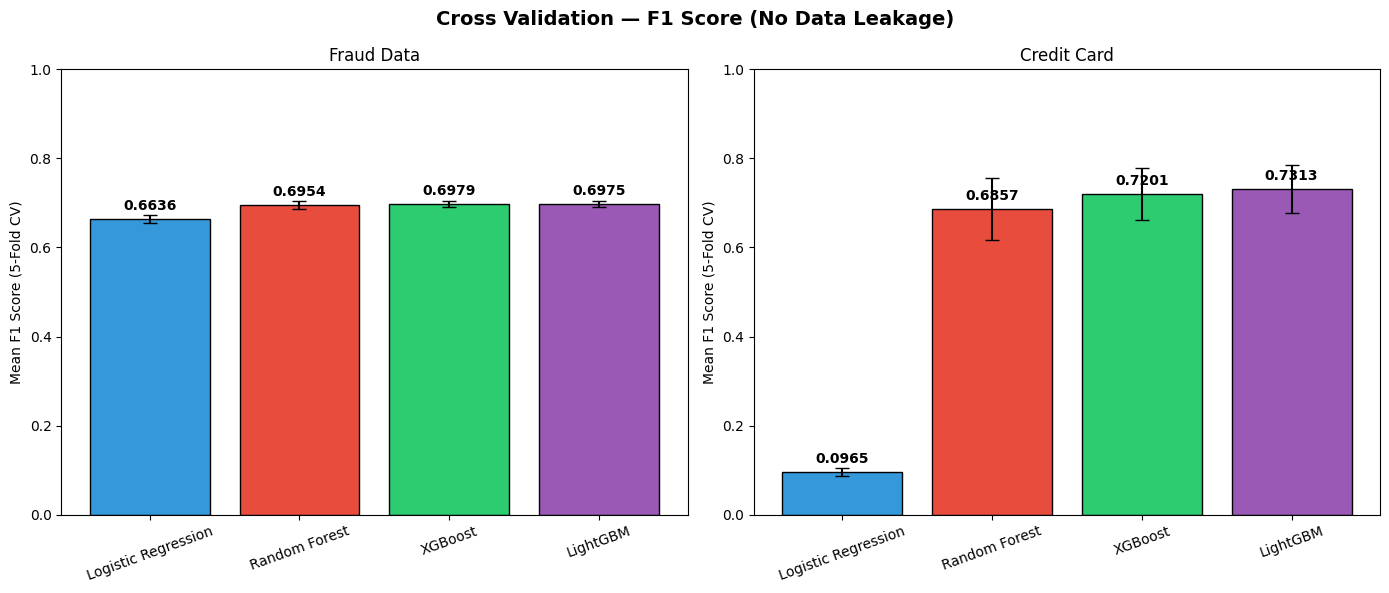

Corrected CV comparison chart saved


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cross Validation — F1 Score (No Data Leakage)',
             fontsize=14, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for idx, dataset in enumerate(['Fraud Data', 'Credit Card']):
    subset = corrected_cv_results[corrected_cv_results['Dataset'] == dataset]

    bars = axes[idx].bar(
        subset['Model'],
        subset['CV Mean F1'],
        yerr=subset['CV Std'],
        capsize=5,
        color=colors,
        edgecolor='black'
    )

    for bar, val in zip(bars, subset['CV Mean F1']):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.4f}',
            ha='center', fontweight='bold', fontsize=10
        )

    axes[idx].set_title(dataset)
    axes[idx].set_ylabel('Mean F1 Score (5-Fold CV)')
    axes[idx].set_ylim(0, 1.0)
    axes[idx].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/processed/corrected_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Corrected CV comparison chart saved")

### Saving the model

In [35]:
import joblib
import os

# Create the models folder if it doesn't already exist
os.makedirs('../models', exist_ok=True)

# --- Logistic Regression (baseline) ---
joblib.dump(lr_model,        '../models/lr_fraud_model.pkl')
joblib.dump(lr_credit_model, '../models/lr_credit_model.pkl')

# --- Random Forest ---
joblib.dump(rf_fraud_model,  '../models/rf_fraud_model.pkl')
joblib.dump(rf_credit_model, '../models/rf_credit_model.pkl')

# --- XGBoost ---
joblib.dump(xgb_fraud_model,  '../models/xgb_fraud_model.pkl')
joblib.dump(xgb_credit_model, '../models/xgb_credit_model.pkl')

# --- LightGBM (our final selected model) ---
joblib.dump(lgb_fraud_model,  '../models/lgb_fraud_model.pkl')
joblib.dump(lgb_credit_model, '../models/lgb_credit_model.pkl')

print("All 8 models saved successfully")
print("\nSaved files:")
print("  → models/lr_fraud_model.pkl")
print("  → models/lr_credit_model.pkl")
print("  → models/rf_fraud_model.pkl")
print("  → models/rf_credit_model.pkl")
print("  → models/xgb_fraud_model.pkl")
print("  → models/xgb_credit_model.pkl")
print("  → models/lgb_fraud_model.pkl  (final selected model)")
print("  → models/lgb_credit_model.pkl (final selected model)")

All 8 models saved successfully

Saved files:
  → models/lr_fraud_model.pkl
  → models/lr_credit_model.pkl
  → models/rf_fraud_model.pkl
  → models/rf_credit_model.pkl
  → models/xgb_fraud_model.pkl
  → models/xgb_credit_model.pkl
  → models/lgb_fraud_model.pkl  (final selected model)
  → models/lgb_credit_model.pkl (final selected model)


### Model Selection Justification

---
## Model Comparison and Selection

### Comparing All Models Side by Side

Four models were trained and evaluated on both datasets:
Logistic Regression, Random Forest, XGBoost, and LightGBM.
To get a reliable comparison, 5-fold stratified cross
validation was used with SMOTE applied correctly inside
each fold to avoid data leakage.

| Model | Fraud Data F1 | Fraud Std | Credit Card F1 | Credit Std |
|---|---|---|---|---|
| Logistic Regression | 0.6636 | 0.0086 | 0.0965 | 0.0089 |
| Random Forest | 0.6954 | 0.0080 | 0.6857 | 0.0699 |
| XGBoost | 0.6979 | 0.0063 | 0.7201 | 0.0594 |
| LightGBM | 0.6975 | 0.0070 | 0.7313 | 0.0542 |

### Performance Comparison

On the fraud dataset all three ensemble models perform
very similarly, scoring between 0.6954 and 0.6979.
Logistic Regression is clearly the weakest at 0.6636.

On the credit card dataset, which has a severe 0.17%
fraud rate, the differences are much larger. LightGBM
achieved the highest score of 0.7313, followed closely
by XGBoost at 0.7201, then Random Forest at 0.6857.
Logistic Regression performs very poorly at 0.0965,
showing it cannot handle this level of imbalance alone.

### Interpretability Comparison

All three ensemble models — Random Forest, XGBoost, and
LightGBM — provide built-in feature importance scores,
allowing the business to understand which features drive
fraud predictions. Logistic Regression is the most
interpretable through its coefficients, but its weak
performance makes it unsuitable as the primary model.

Among the ensemble models, all three support SHAP for
deeper explainability, which will be used in Task 3.
This means the choice between them can be made primarily
on performance, since interpretability is comparable
across all three.

### Selected Model — LightGBM

LightGBM is selected as the best model for the following
reasons.

**Reason 1 — Highest Score on the Hardest Dataset**
LightGBM achieved the highest F1 score of 0.7313 on the
credit card dataset, which is the more challenging of the
two due to its extreme 0.17% fraud rate. Performing best
on the hardest problem is the strongest evidence of a
model's real-world value.

**Reason 2 — Most Consistent Performance**
LightGBM had the lowest standard deviation (0.0542) among
the ensemble models on credit card data, meaning its
performance is the most stable and predictable across
different data folds.

**Reason 3 — Competitive on Fraud Data**
On the fraud dataset, LightGBM scored 0.6975, virtually
identical to XGBoost (0.6979) and ahead of Random Forest
(0.6954), confirming it does not sacrifice performance
on the easier dataset to win on the harder one.

**Reason 4 — Equally Interpretable**
LightGBM supports both built-in feature importance and
SHAP explainability, matching Random Forest and XGBoost
in this regard, so no interpretability is sacrificed by
choosing it.

**Reason 5 — Efficient**
LightGBM is known for being fast and memory efficient,
which is valuable for a real-time fraud detection system
that needs to score transactions quickly.

### Why Not the Other Models

Logistic Regression was rejected due to its very poor
performance on credit card data (0.0965), making it
unsuitable despite its simplicity and interpretability.

Random Forest was outperformed by both XGBoost and
LightGBM on credit card data and offered no advantage
in interpretability to compensate.

XGBoost was a very close second to LightGBM, scoring
0.7201 on credit card data with similar interpretability.
LightGBM was preferred due to its slightly higher score
and lower variance, but XGBoost remains a strong
alternative if needed.